In [2]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

In [3]:
def generate_caption_with_finetuned(model_path, image_input, max_length=100, num_beams=5, temperature=1.0, display_image=True):
    """
    Génère une légende avec votre modèle BLIP fine-tuné
    
    Args:
        model_path (str): Chemin vers votre modèle fine-tuné
        image_input (str): Chemin local ou URL de l'image
        max_length (int): Longueur max de la légende
        num_beams (int): Nombre de beams pour la recherche
        temperature (float): Créativité (1.0 = standard)
        display_image (bool): Afficher l'image ou non
    
    Returns:
        str: Légende générée
    """
    # 1. Chargement du modèle fine-tuné
    device = "cuda" if torch.cuda.is_available() else "cpu"
    processor = BlipProcessor.from_pretrained(model_path)
    model = BlipForConditionalGeneration.from_pretrained(model_path).to(device)
    
    # 2. Chargement de l'image
    try:
        if image_input.startswith(('http://', 'https://')):
            image = Image.open(requests.get(image_input, stream=True).raw).convert("RGB")
        else:
            image = Image.open(image_input).convert("RGB")
    except Exception as e:
        raise ValueError(f"Erreur de chargement de l'image: {e}")
    
    # 3. Affichage (optionnel)
    if display_image:
        plt.figure(figsize=(8, 8))
        plt.imshow(image)
        plt.axis('off')
        plt.show()
    
    # 4. Génération de la légende
    inputs = processor(image, return_tensors="pt").to(device)
    
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        num_beams=num_beams,
        temperature=temperature,
        early_stopping=True
    )
    
    caption = processor.decode(outputs[0], skip_special_tokens=True)
    
    return caption

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
/home/pionners03/projects/afroAnnotation/annot_venv/lib/python3.12/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


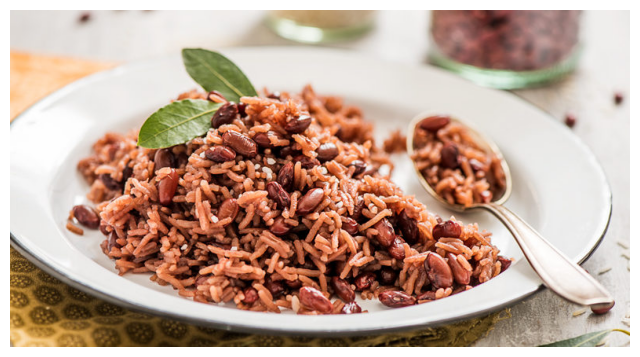

',,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,'

In [4]:
generate_caption_with_finetuned(
    model_path="../models/blip-afro-food",
    image_input="https://www.monquotidienautrement.com/wp-content/uploads/2018/03/atassi-790x430.jpg",
    max_length=100,
    num_beams=5,
    temperature=1.0,
    display_image=True
)

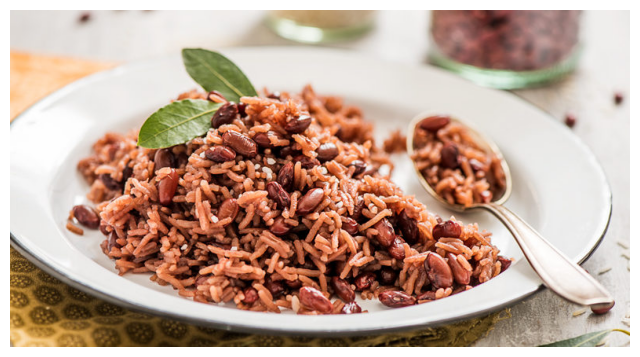

'the image shows a plate of waakye, a ghanaian dish made of rice and beans, with a reddish - brown color likely from the use of dried millet leaves, and visible grains of rice and beans are mixed together, giving it a rich, reddish - brown color'

In [5]:
generate_caption_with_finetuned(
    model_path="../models/blip-afro-food-v1.1",
    image_input="https://www.monquotidienautrement.com/wp-content/uploads/2018/03/atassi-790x430.jpg",
    max_length=100,
    num_beams=5,
    temperature=1.0,
    display_image=True
)